# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [2]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [12]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [13]:
df.info()
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB
Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64


In [14]:
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.duplicated().sum())

598
0


# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

No uso de modelos é bom normalizar? não alteraria a análise "forçar"? ou não já que mantémas relações dentro da variável? Não, o que muda é o coeficiente. Na verdade é até bom porque melhora a interpretação e estabilidade numérica. Mas não pode a variável que você que prever.

In [17]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000
mean,3024.524905,829.178804,89.655413,2.305072,2.104164,1.020288,1.452990
std,3022.964453,811.521280,62.963890,0.833349,1.000631,0.888489,0.886046
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.000000
25%,1400.000000,400.000000,52.000000,2.000000,2.000000,1.000000,1.000000
50%,2000.000000,600.000000,68.000000,2.000000,2.000000,1.000000,1.000000
75%,3400.000000,1000.000000,101.000000,3.000000,2.000000,1.000000,2.000000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.000000


	Valor_Aluguel: a média de 3024,52 é 1000 maior que a mediana 2000 indicando uma certa assimetria onde possíveis valores mais altos elevam a média com o dp também alto indicando um espalhamento dos dados.
   
    Valor_Condomínio: média de 829 superior a mediana de 600 indicando também a presença de alguns valores mais altos e dp também alto indicando um espalhamento dos dados.
    
    Metragem: média de 89 mediana de 68 indica uma distribuição mais irregular e o dp também indica certo espalhamento
    
    N_Quartos: média muto próxima da mediana indica uma distribuição mais regular já o dp não indica grande dispersão dos dados.
    
    N_banheiros: média muito próxima da mediana indica uma distribuição mais regular já o dp não indica grande dispersão dos dados.
    
    N_Suites: média muito próxima da mediana indica uma distribuição mais regular já o dp não indica grande dispersão dos dados.
    
    N_Vagas: média muito próxima da mediana indica uma distribuição mais regular já o dp não indica grande dispersão dos dados.
    

In [15]:
df.columns = df.columns.str.lower()
df.columns

Index(['valor_aluguel', 'valor_condominio', 'metragem', 'n_quartos',
       'n_banheiros', 'n_suites', 'n_vagas'],
      dtype='str')

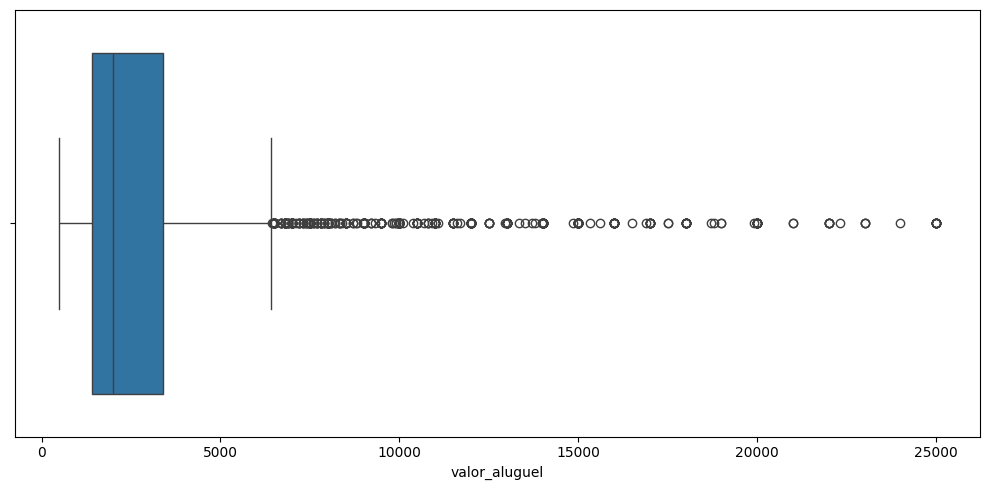

In [36]:
plt.figure(figsize=(10, 5)) 
sns.boxplot(x=df['valor_aluguel'])
plt.tight_layout()
plt.show()
#A variável valor do aluguel realmente possui muitos outliers, mas como ela é o objeto que será previsto e alterar substituindo pela média pode distorcer as previsões do
#modelo optei por manter

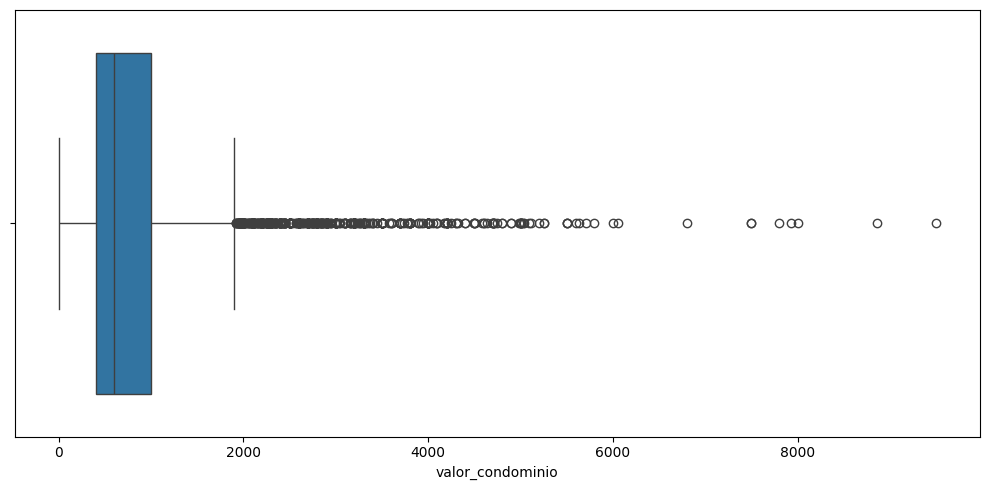

In [53]:
plt.figure(figsize=(10, 5)) 
sns.boxplot(x=df['valor_condominio'])
plt.tight_layout()
plt.show() 
#já que o valor do condomínio deve também ser sensível optei por manter os valores extremos.

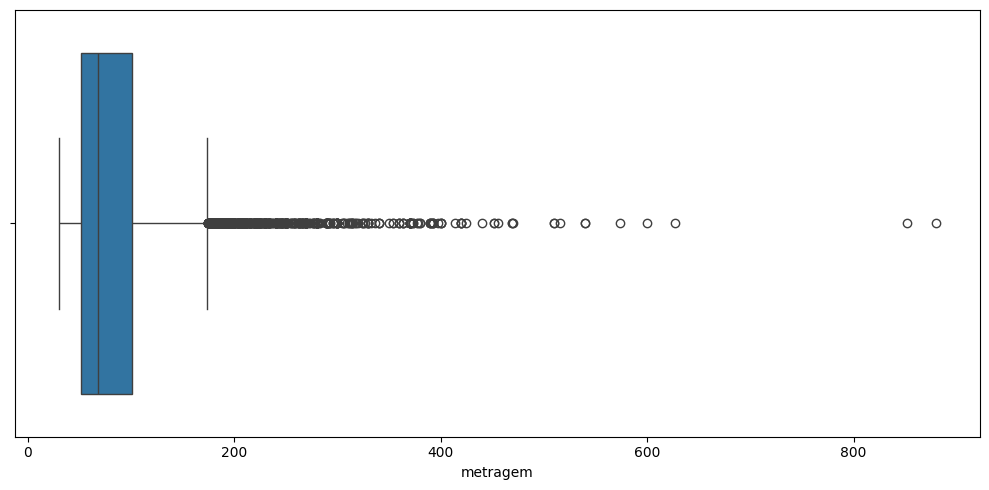

In [38]:
plt.figure(figsize=(10, 5)) 
sns.boxplot(x=df['metragem'])
plt.tight_layout()
plt.show()
#já que o valor deve também ser sensível optei por manter os valores extremos.

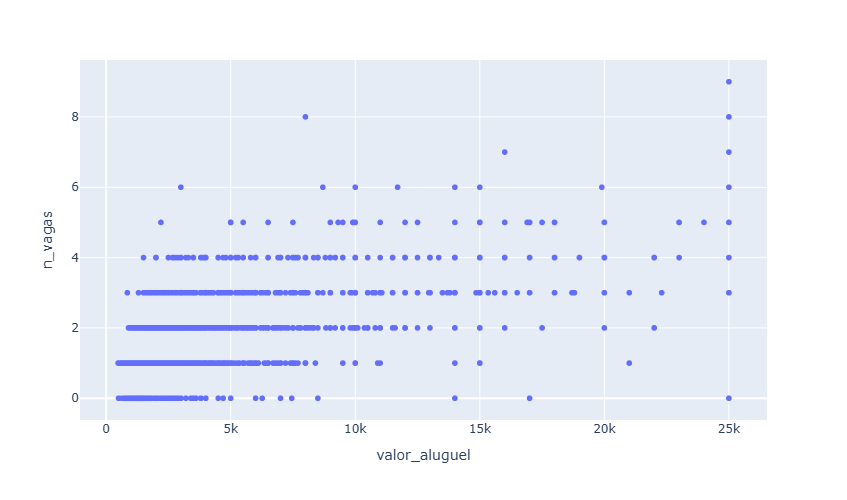

In [74]:
fig = px.scatter(
    df,
    x='valor_aluguel',
    y='n_vagas',
    title=''
)
fig.update_layout(width=800, height=500)
fig.show()

#os dados indicam que aluguéis sem vaga tendem a ser mais baratos, com um gava adquirem uma distribuição maior. Entretanto, acima de duas vagas
# a relação entre número de vagas e valor do aluguel se torna menos evidente. Talvez porque no geral o grupo presente no banco de dados possui apenas um carro.

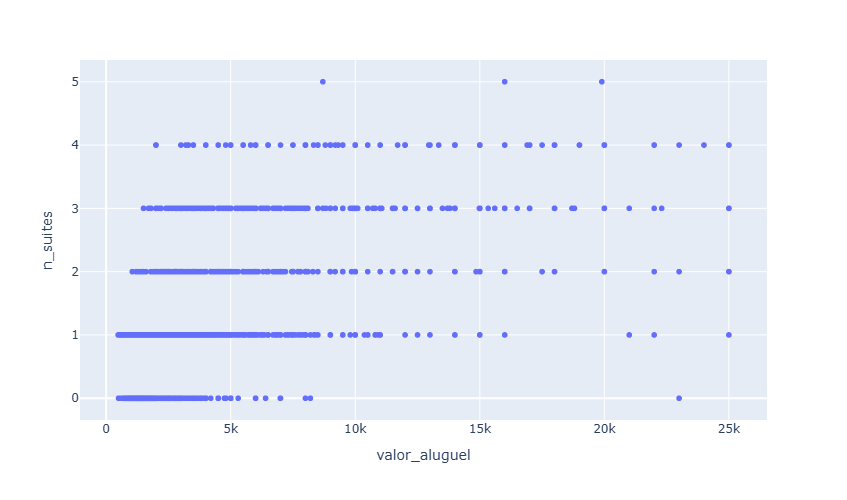

In [73]:
fig = px.scatter(
    df,
    x='valor_aluguel',
    y='n_suites',
    title=''
)
fig.update_layout(width=800, height=500)

fig.show()
#os dados indicam que aluguéis sem suites tendem a ser mais baratos, com uma suite adquirem uma distribuição maior. Entretanto, acima de uma
# a relação entre número de vagas e valor do aluguel se torna menos evidente. Talvez porque a preferência por um quarto com banheiro seja grande, mas apenas um já supra a necessidade dos integrantes do banco de dados.


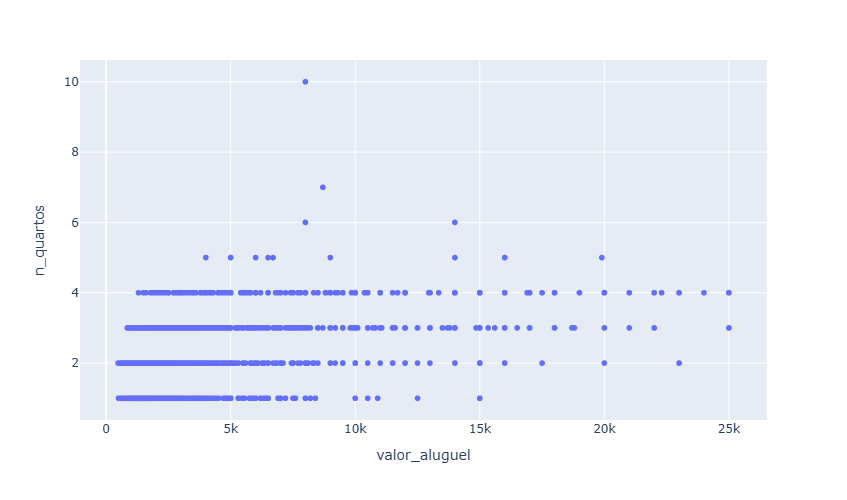

In [72]:
fig = px.scatter(
    df,
    x='valor_aluguel',
    y='n_quartos',
    title=''
)
fig.update_layout(width=800, height=500)

fig.show()
#os dados indicam que aluguéis com um quarto tendem a ser mais baratos, com dois quartos adquirem uma distribuição maior. Entretanto, acima de dois
# a relação entre número de quartos e valor do aluguel se torna menos evidente. Talvez porque o público dos dados possua preferências como um quarto para escritório 
#ou para criança e os comodos acima disso não seriam uma necessidade.

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




In [75]:
df.corr()

,valor_aluguel,valor_condominio,metragem,n_quartos,n_banheiros,n_suites,n_vagas
valor_aluguel,1.000000,0.695416,0.732955,0.420922,0.607061,0.619733,0.657143
valor_condominio,0.695416,1.000000,0.807445,0.501931,0.591799,0.595933,0.692020
metragem,0.732955,0.807445,1.000000,0.679294,0.689502,0.699391,0.745466
n_quartos,0.420922,0.501931,0.679294,1.000000,0.555867,0.541976,0.598451
n_banheiros,0.607061,0.591799,0.689502,0.555867,1.000000,0.918375,0.698761
n_suites,0.619733,0.595933,0.699391,0.541976,0.918375,1.000000,0.717703
n_vagas,0.657143,0.692020,0.745466,0.598451,0.698761,0.717703,1.000000


Aluguel apresenta forte correlação positiva com todas as variáveis, sendo a mais forte delas com a metragem. Seguida do valor do condomínio, n_vagas, n_suites, -_banheiros e por fim n_quartos. 


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [95]:
X = df.drop('valor_aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['valor_aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [96]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.25, random_state =42)

In [81]:
print('tamanho', X_train.shape)

tamanho (4953, 6)


In [82]:
print(X_train.columns)

Index(['valor_condominio', 'metragem', 'n_quartos', 'n_banheiros', 'n_suites',
       'n_vagas'],
      dtype='str')


In [83]:
print('tamanho', X_test.shape)

tamanho (1652, 6)


In [84]:
print('tamanho', Y_train.shape)

tamanho (4953,)


In [85]:
print('tamanho', Y_test.shape)

tamanho (1652,)


# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [111]:
df['metragem'].corr(df['valor_aluguel']) #forte correlação positiva entre a metragem e o aluguel indicando um aumento de ambas 
#Crie seu modelo aqui, usando LinearRegression e as bases de treino.


np.float64(0.7329549491691584)

In [105]:
X = df[['metragem']]
y = df['valor_aluguel']

In [106]:
X = X_train[['metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)- não recebe nada, já é só uma coluna.
# se você deu um nome diferente para x train e y train, altere no código.

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [115]:
regressao_valor_aluguel.intercept_

np.float64(-204.7333453813185)

In [116]:
regressao_valor_aluguel.coef_

array([36.4610016])

Nossa equação seria:  v_aluguel = -204,73 + 36.46 * metragem

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [118]:
regressao_valor_aluguel.score(X,y) #aqui é td r e sim indica que 53 da variação na variável dependente e explicada pela variável independente. 

0.537788824289692

In [119]:
regressao_valor_aluguel.score(X_test, y_test) # aqui é só o do teste que apesar dos erros também é um bom resultado.

0.4767010027036699

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

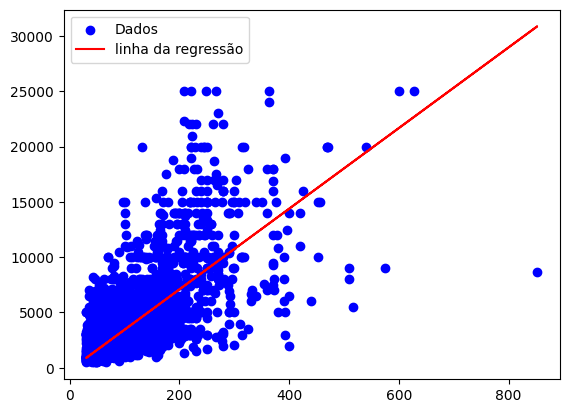

In [121]:
plt.scatter(X,y, color = 'blue', label = 'Dados')
plt.plot(X, regressao_valor_aluguel.predict(X), color = 'red', label = 'linha da regressão')
plt.legend()

#47% da variação na variável dependente e explicada pela variável independente apesar de nem todos os ponts estarem alinhados com a reta 
#uma boa proporção deles está.

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [ ]:
X_test = X_test[['Metragem']]  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo) só p visualizar

In [123]:
regressao_valor_aluguel = LinearRegression()
regressao_valor_aluguel.fit(X_train, y_train)
y_valor1 = regressao_valor_aluguel.predict(X_test)

In [124]:
print(y_valor1)

[2165.23175853 1363.08972336 1436.01172656 ... 1691.23873775 2602.76377772
 1618.31673455]


In [ ]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
#previsoes = SEUMODELO.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
#r2 = SEUMODELO.score(X_test, y_test)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.5651600449476675


In [122]:
r2 = regressao_valor_aluguel.score(X_test, y_test)
print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)

Coeficiente de Determinação (R²) nos Dados de Teste: 0.4767010027036699


In [120]:

resultado = pd.DataFrame({
    'real': y_test,
    'previsto': y_valor1
})

print(resultado.head(20))

       real      previsto
5996   4200   2165.231759
6298   5000   1363.089723
2403   1500   1436.011727
1533   1300   2092.309755
2795   1600   2712.146783
24      650   1180.784715
4983   2820   5483.182904
5189   3000   1034.940709
183     850   2165.231759
6737   7700   8181.297022
3989   2200   4061.203842
5285   3000    925.557704
534    1000   2347.536767
4132   2220   3441.366814
2488   1500   2712.146783
4266   2322   5884.253922
6655   7000   1800.621743
5327   3100   1399.550725
7023  12000  13577.525259
661    1050   2456.919771


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

Escreva sua resposta aqui.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

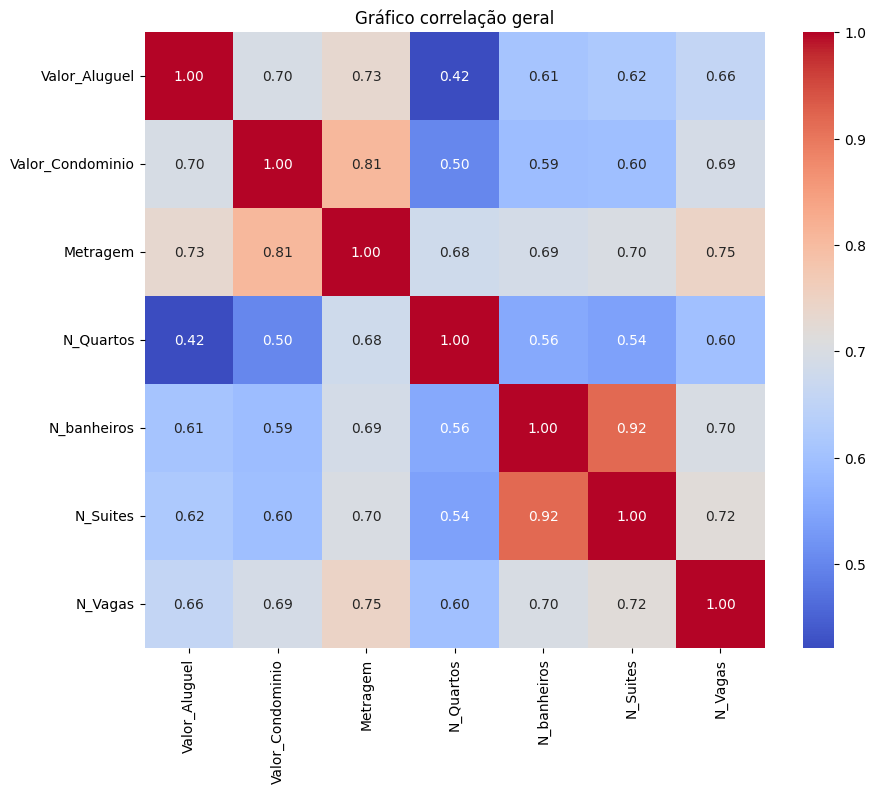

In [9]:
correlacao = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Gráfico correlação geral')
plt.show() #avaliando visualmente a relação das variáveis com o aluguel. 
#É preciso tomar cuidado com variáveis altamente correlacionadas entre si como metragem e modelo.

B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [23]:

X = df[['valor_condominio', 'metragem', 'n_quartos', 
        'n_banheiros', 'n_suites', 'n_vagas']]

y = df['valor_aluguel']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


modelo = LinearRegression()
modelo.fit(X_train, y_train)
print(modelo.coef_)

[   0.77423358   21.67913878 -705.70125086  191.69642351  429.4273969
  578.7978232 ]


C) Traga o valor do R quadrado e avalie o valor encontrado.

In [24]:
r2_treino = modelo.score(X_train, y_train)
print(r2_treino)

0.615697288633301


D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [25]:
r2_teste = modelo.score(X_test, y_test)
print(r2_teste)

0.5751243529094872


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

R. Linear= 0.47
R. Multipla= 0.57
O modelo com maior r^2 porque as variaveis independentes explicariam uma também maior porcentagem de resultados da variável dependente. No caso o modelo que usa a regressão multipla, já que a adição de outras variáveis dependentes pode ajudar de forma não linear para a precisão do modelo. 